In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import utils
import os

input_directory = r"E:\Users\Sebastian_van_Dijk\TEMP"
organoids = ["TL01", "TL09","TL10","TL11","TL12","TL31"]
dirs = []
for organoid in organoids:
    dir_path = os.path.join(input_directory, organoid, "properties")
    dirs.append(dir_path)

all_df = pd.DataFrame()
for organoid, directory in zip(organoids, dirs):
    for file in os.listdir(directory):
        if file.endswith(".txt"):
            df = pd.read_csv(os.path.join(directory, file), sep="\t")
            if organoid == "TL01":
                df["type"] = "WT"
            elif organoid == "TL26":
                df["type"] = "CRC"
            else:
                df["type"] = "mixed"
            df["organoid"] = organoid
            all_df = pd.concat([all_df, df], ignore_index=True)

all_df["ratioWT_CRC"] = all_df["raw_WT"] / all_df["raw_CRC"]



Welcome to CellposeSAM, cellpose v
cellpose version: 	4.0.5 
platform:       	win32 
python version: 	3.11.13 
torch version:  	2.7.1+cpu! The neural network component of
CPSAM is much larger than in previous versions and CPU excution is slow. 
We encourage users to use GPU/MPS if available. 


utils package loaded successfully


FileNotFoundError: [WinError 3] The system cannot find the path specified: 'E:\\Users\\Sebastian_van_Dijk\\TEMP\\TL01\\properties'

In [15]:
df

,label,z,y,x,bounding_box,volume,area_WT,raw_WT,area_CRC,raw_CRC,Phenotype,type,organoid
0,1,1.592878,31.710720,145.026432,"(0, 17, 121, 5, 50, 172)",2724.0,2724.0,107.593245,2724.0,139.082232,CRC,mixed,TL31
1,2,0.502924,66.688304,178.958480,"(0, 51, 162, 2, 84, 198)",1710.0,1710.0,107.840351,1710.0,147.695322,CRC,mixed,TL31
2,3,0.428212,75.352645,115.767003,"(0, 60, 105, 2, 90, 127)",794.0,794.0,108.108312,794.0,129.226700,CRC,mixed,TL31
3,4,0.500000,87.396175,198.342896,"(0, 74, 188, 2, 102, 209)",732.0,732.0,108.256831,732.0,148.155738,CRC,mixed,TL31
4,5,0.365912,100.827175,150.847437,"(0, 85, 141, 2, 117, 162)",839.0,839.0,108.052443,839.0,129.520858,CRC,mixed,TL31
...,...,...,...,...,...,...,...,...,...,...,...,...,...
305,306,22.197531,202.190329,213.412551,"(21, 189, 203, 24, 216, 223)",972.0,972.0,107.884774,972.0,114.017490,CRC,mixed,TL31
306,307,21.000000,211.465909,138.431818,"(21, 204, 132, 22, 221, 146)",176.0,176.0,108.034091,176.0,117.556818,CRC,mixed,TL31
307,308,21.515982,220.223744,237.465753,"(21, 214, 232, 23, 227, 244)",219.0,219.0,107.214612,219.0,121.447489,CRC,mixed,TL31
308,309,22.165574,229.445902,208.193443,"(21, 221, 198, 24, 238, 218)",610.0,610.0,107.824590,610.0,117.613115,CRC,mixed,TL31


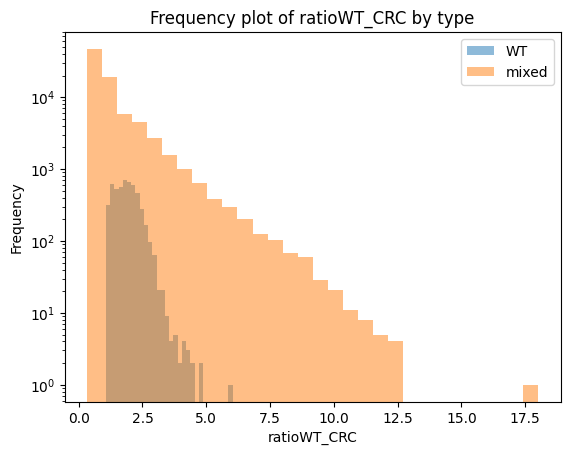

In [13]:
for t in all_df["type"].unique():
    subset = all_df[all_df["type"] == t]
    plt.hist(subset["ratioWT_CRC"], bins=30, alpha=0.5, label=t)

plt.xlabel("ratioWT_CRC")
plt.ylabel("Frequency")
plt.title("Frequency plot of ratioWT_CRC by type")
plt.yscale("log")  # Make y-axis logarithmic
plt.legend()
plt.show()

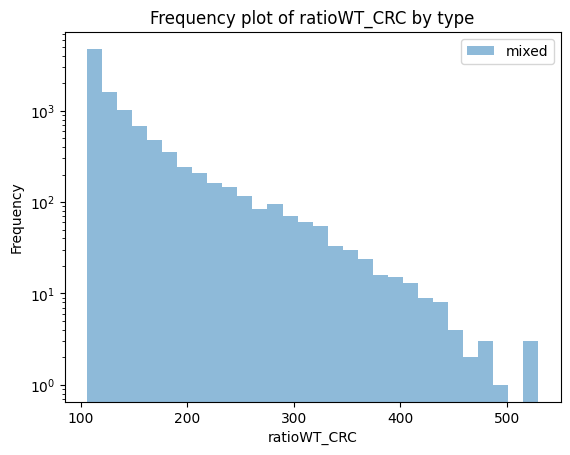

In [18]:
subset = all_df[all_df["organoid"] == "TL11"]
plt.hist(subset["raw_WT"], bins=30, alpha=0.5, label=t)

plt.xlabel("ratioWT_CRC")
plt.ylabel("Frequency")
plt.title("Frequency plot of ratioWT_CRC by type")
plt.yscale("log")  # Make y-axis logarithmic
plt.legend()
plt.show()

In [ ]:
import tifffile
import esda
import libpysal
import numpy as np

import os


image = tifffile.imread(r"E:\Users\Sebastian_van_Dijk\TEMP\TL11\projXY.tif")[:, row_min:row_max, col_min:col_max]

XZ = np.stack(image, axis=1)


In [6]:
import tifffile
from scipy import ndimage
import os

input_directory = r"C:\Users\6331823\Desktop\Train model whole organoid segmentation"
for organoid in os.listdir(input_directory):
    if organoid.endswith(".tif"):
        original = os.path.join(input_directory, organoid)
        original = tifffile.imread(original)
        resize_factors = (200 / original.shape[0] , 200 / original.shape[1])
        XY = ndimage.zoom(original, resize_factors, order=0)
        XY = ndimage.gaussian_filter(XY, sigma=(2, 2))
        tifffile.imwrite(
            os.path.join(input_directory, "smoothed_XY", organoid),
            XY,
        )

In [ ]:
import numpy as np
from sklearn.cluster import KMeans
import pandas as pd

# Your ratio data
ratios = np.array([
    0.843218545, 0.844873502, 1.668776133, 0.862274271, 0.809498911,
    0.737159537, 0.845353398, 0.775946006, 0.674322713, 0.649706156,
    1.112518394, 0.81620095, 1.705073941, 0.753885069, 0.77938578,
    0.793327383, 1.982575108, 0.737841096, 0.704847086, 0.701849541,
    0.847186436, 0.688447415, 0.695395085, 0.757498956, 1.13937129,
    2.126445938, 0.866231304, 2.3231805, 0.77348789, 0.761823995,
    0.773913337, 0.693962019, 0.760776805, 1.720121879, 0.753178687,
    1.351161179, 1.430329714, 0.846986397, 0.735142857, 1.350898729,
    1.972850816, 1.428831122, 1.641974047, 1.413566286, 0.810866686,
    0.837289092, 1.257008415, 0.869855683, 0.873884474, 0.865940501,
    0.908263305, 1.440489263, 1.289546879, 0.784626411, 0.888552437,
    0.822779145, 0.84824339
]).reshape(-1, 1)  # reshape for sklearn

for frame in range(14):
    ratios = pd.read_csv(f"E:\\Users\\Sebastian_van_Dijk\\Data_Anna\\s65\\properties\\Frame-{frame}_props.csv")
    ratios = ratios["wt_crc_ratio"].to_numpy().reshape(-1, 1)

    # Run KMeans with 2 clusters
    kmeans = KMeans(n_clusters=2, random_state=0)
    labels = kmeans.fit_predict(ratios)
    centers = kmeans.cluster_centers_.flatten()

    # Sort cluster centers to get lower and upper cluster means
    centers.sort()
    cutoff = (centers[0] + centers[1]) / 2

    print(f"frame: {frame}")
    print("Cluster centers:", centers)
    print("Estimated cutoff value:", cutoff)
    #cutoff = 1

    print(f"CRC cells: {np.sum(ratios.flatten() < cutoff)}")
    print(f"WT cells: {np.sum(ratios.flatten() >= cutoff)}\n")


frame: 0
Cluster centers: [0.80490334 1.5987637 ]
Estimated cutoff value: 1.201833517612973
CRC cells: 38
WT cells: 17

frame: 1
Cluster centers: [0.81025005 1.59913951]
Estimated cutoff value: 1.2046947819564797
CRC cells: 56
WT cells: 18

frame: 2
Cluster centers: [0.8431325  1.75521769]
Estimated cutoff value: 1.2991750972770781
CRC cells: 83
WT cells: 17

frame: 3
Cluster centers: [0.84671004 1.62655394]
Estimated cutoff value: 1.2366319891124362
CRC cells: 112
WT cells: 20

frame: 4
Cluster centers: [0.86165762 1.63344464]
Estimated cutoff value: 1.247551133147449
CRC cells: 159
WT cells: 22

frame: 5
Cluster centers: [0.85421118 1.63587196]
Estimated cutoff value: 1.245041572590544
CRC cells: 205
WT cells: 24

frame: 6
Cluster centers: [0.85839238 1.73696882]
Estimated cutoff value: 1.2976806005872792
CRC cells: 259
WT cells: 23

frame: 7
Cluster centers: [0.84025978 1.52140253]
Estimated cutoff value: 1.1808311579876176
CRC cells: 319
WT cells: 34

frame: 8
Cluster centers: [0.8

In [11]:

input_directory = r"C:\Users\6331823\Local SSD\s65"

segmented = os.path.join(input_directory, "segmented")
cropped = os.path.join(input_directory, "cropped")
WT_channel = 0
CRC_channel = 1

for file in range(15):
    segmented_stack = tifffile.imread(os.path.join(segmented, f"Frame-{file}_masks.tif"))
    frame = tifffile.imread(os.path.join(cropped, f"Frame-{file}.tif"))

    # Get properties of the masked nuclei, such as volume and location of every cell
    props = utils.properties_mask(segmented_stack)

    # Get properties of every cell in the WT and CRC channels at the masked nuclei locations
    frame_WT = frame[WT_channel, :, :, :]
    df_wt = utils.properties_channel(segmented_stack, frame_WT, "WT")

    frame_CRC = frame[CRC_channel, :, :, :]
    df_crc = utils.properties_channel(segmented_stack, frame_CRC, "CRC")

    # Combine the information of nuclei, WT, and CRC channel into a single dataframe
    df_final = props.merge(df_wt, on="label").merge(df_crc, on="label")
    df_final['wt_crc_ratio'] = df_final.apply(
        lambda row: row['raw_WT'] / row['raw_CRC'] if row['raw_CRC'] != 0 else 5,
        axis=1
    )

    ratios = df_final["wt_crc_ratio"].to_numpy().reshape(-1, 1)

    # Run KMeans with 2 clusters
    kmeans = KMeans(n_clusters=2, random_state=0)
    labels = kmeans.fit_predict(ratios)
    centers = kmeans.cluster_centers_.flatten()

    # Sort cluster centers to get lower and upper cluster means
    centers.sort()
    cutoff = (centers[0] + centers[1]) / 2

    print(f"frame: {file}")
    print("Cluster centers:", centers)
    print("Estimated cutoff value:", cutoff)
    # cutoff = 1

    print(f"CRC cells: {np.sum(ratios.flatten() < cutoff)}")
    print(f"WT cells: {np.sum(ratios.flatten() >= cutoff)}\n")

frame: 0
Cluster centers: [0.80490334 1.5987637 ]
Estimated cutoff value: 1.201833517612973
CRC cells: 38
WT cells: 17

frame: 1
Cluster centers: [0.81025005 1.59913951]
Estimated cutoff value: 1.2046947819564797
CRC cells: 56
WT cells: 18

frame: 2
Cluster centers: [0.8431325  1.75521769]
Estimated cutoff value: 1.2991750972770781
CRC cells: 83
WT cells: 17

frame: 3
Cluster centers: [0.84671004 1.62655394]
Estimated cutoff value: 1.2366319891124364
CRC cells: 112
WT cells: 20

frame: 4
Cluster centers: [0.86165762 1.63344464]
Estimated cutoff value: 1.247551133147449
CRC cells: 159
WT cells: 22

frame: 5
Cluster centers: [0.85421118 1.63587196]
Estimated cutoff value: 1.245041572590544
CRC cells: 205
WT cells: 24

frame: 6
Cluster centers: [0.85839238 1.73696882]
Estimated cutoff value: 1.2976806005872792
CRC cells: 259
WT cells: 23

frame: 7
Cluster centers: [0.84025978 1.52140253]
Estimated cutoff value: 1.1808311579876176
CRC cells: 319
WT cells: 34

frame: 8
Cluster centers: [0.8

In [13]:
import utils
from sklearn.mixture import GaussianMixture
import os
import numpy as np
import pandas as pd
import tifffile

In [95]:
input_directory = r"C:\Users\6331823\Local SSD\Data_Anna\mixed\EXpansionLMix_12"


segmented = os.path.join(input_directory, "segmented")
cropped = os.path.join(input_directory, "cropped")
WT_channel = 0
CRC_channel = 1
all_ratios = []
frame_data = []


for file in range(len(os.listdir(segmented))):
    segmented_stack = tifffile.imread(
        os.path.join(segmented, f"Frame-{file}_masks.tif")
    )


    frame = tifffile.imread(os.path.join(cropped, f"Frame-{file}.tif"))

    # Get properties of the masked nuclei, such as volume and location of every cell
    props = utils.properties_mask(segmented_stack)

    # Get properties of every cell in the WT and CRC channels at the masked nuclei locations
    frame_WT = frame[WT_channel, :, :, :]
    # threshold = frame_WT.copy()
    # threshold = utils.threshold(threshold)
    # blurred = ndimage.gaussian_filter(threshold, sigma=(0, 2, 2))

    median_value = np.median(frame_WT[frame_WT > 0])
    offset_WT = frame_WT.astype(np.float32) - median_value
    offset_WT[offset_WT < 0] = 0  # Clip negative values
    offset_WT = np.clip(offset_WT, 0, 255).astype(np.uint16)
    df_wt = utils.properties_channel(segmented_stack, offset_WT, "WT")


    frame_CRC = frame[CRC_channel, :, :, :]
    median_value = np.median(frame_CRC[frame_CRC > 0])
    offset_CRC = frame_CRC.astype(np.float32) - median_value
    offset_CRC[offset_CRC < 0] = 0  # Clip negative values
    offset_CRC = np.clip(offset_CRC, 0, 255).astype(np.uint16)
    df_crc = utils.properties_channel(segmented_stack, offset_CRC, "CRC")


    # Combine the information of nuclei, WT, and CRC channel into a single dataframe
    df_final = props.merge(df_wt, on="label").merge(df_crc, on="label")
    df_final["file"] = file
    df_final["wt_crc_ratio"] = df_final.apply(
        lambda row: row["raw_WT"] / row["raw_CRC"] if row["raw_CRC"] != 0 else 5, axis=1
    )
    df_final["log_ratio"] = np.log10(df_final['wt_crc_ratio'] + 1e-6)
    frame_data.append(df_final)


properties = pd.concat(frame_data, ignore_index=True)

ratios2 = properties["log_ratio"].to_numpy().reshape(-1, 1)

-1.0329849607507833


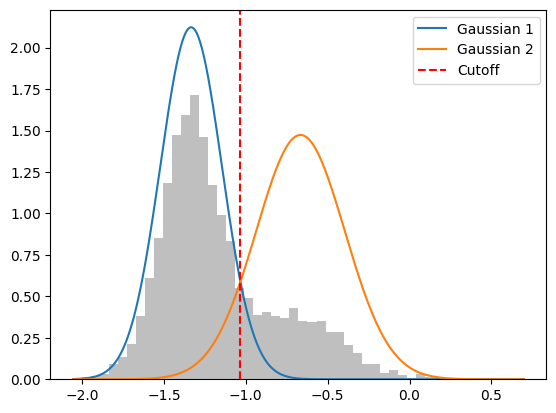

In [94]:
# Assuming ratios is already in shape (-1, 1)
gmm = GaussianMixture(n_components=2, random_state=0)
gmm.fit(ratios)

# Predict cluster labels
gmm_labels = gmm.predict(ratios)

# Access the means of the Gaussian components
means = gmm.means_.flatten()
means.sort()  # Sorted so you know which is the low/high cluster

variances = gmm.covariances_.flatten()
stds = np.sqrt(variances)

# Separate the clusters
group_low = ratios[gmm_labels == np.argmin(means)]
group_high = ratios[gmm_labels == np.argmax(means)]

# Use the means and stds from your GMM
mu1, mu2 = means
sigma1, sigma2 = stds
x_vals = np.linspace(ratios.min(), ratios.max(), 1000)

def plot_normal(x, mean = 0, sigma = 1):
    return 1.0/np.sqrt(2*np.pi*sigma**2) * np.exp(-((x-mean)**2)/(2*sigma**2))

# found online
def solve_gasussians(m1, s1, m2, s2):
  a = 1.0/(2.0*s1**2) - 1.0/(2.0*s2**2)
  b = m2/(s2**2) - m1/(s1**2)
  c = m1**2 /(2*s1**2) - m2**2 / (2.0*s2**2) - np.log(s2/s1)
  return np.roots([a,b,c])

solved_val = solve_gasussians(mu1, sigma1, mu2, sigma2)
cutoff = sorted(solved_val)[-1]
print(cutoff)

# Plot as before
plt.hist(ratios, bins=50, density=True, alpha=0.5, color="gray")
x_vals = np.linspace(ratios.min(), ratios.max(), 1000)
pdf1 = norm(mu1, sigma1).pdf(x_vals)
pdf2 = norm(mu2, sigma2).pdf(x_vals)
plt.plot(x_vals, pdf1, label="Gaussian 1")
plt.plot(x_vals, pdf2, label="Gaussian 2")
plt.axvline(cutoff, color="red", linestyle="--", label="Cutoff")
plt.legend()
plt.show()

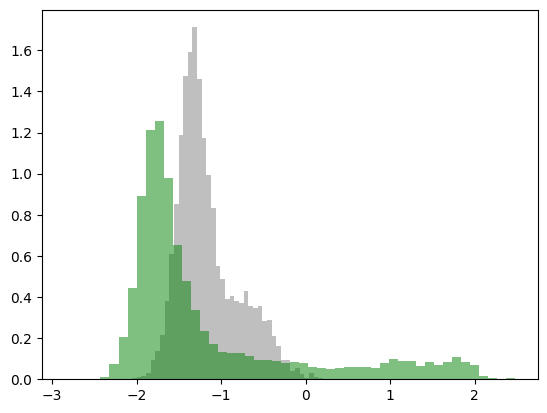

In [96]:
plt.hist(ratios, bins=50, density=True, alpha=0.5, color="gray")
plt.hist(ratios2, bins=50, density=True, alpha=0.5, color="green")
plt.show()

In [ ]:
summary_results = []
for number in range():
    df = properties[properties["file"] == number]
    crc_count = np.sum(df["log_ratio"] < cutoff)
    wt_count = np.sum(df["log_ratio"] >= cutoff)
    total = crc_count + wt_count

    results = {
        "file": number,
        "wt_count": wt_count,
        "crc_count": crc_count,
        "%wt": wt_count / total * 100,
        "%crc": crc_count / total * 100,
    }
    summary_results.append(pd.DataFrame([results]))

summary_results = pd.concat(summary_results, ignore_index=True)

    file  wt_count  crc_count        %wt       %crc
0      0       158         11  93.491124   6.508876
1      1       201          8  96.172249   3.827751
2      2       258         15  94.505495   5.494505
3      3       299         15  95.222930   4.777070
4      4       390          8  97.989950   2.010050
5      5       423         47  90.000000  10.000000
6      6       543         41  92.979452   7.020548
7      7       609         57  91.441441   8.558559
8      8       758         63  92.326431   7.673569
9      9       849         70  92.383025   7.616975
10    10       901         97  90.280561   9.719439
11    11      1034        107  90.622261   9.377739
12    12      1083        183  85.545024  14.454976
13    13      1338        174  88.492063  11.507937


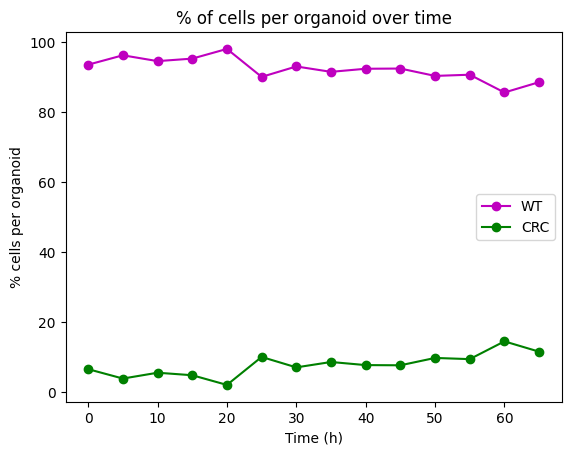

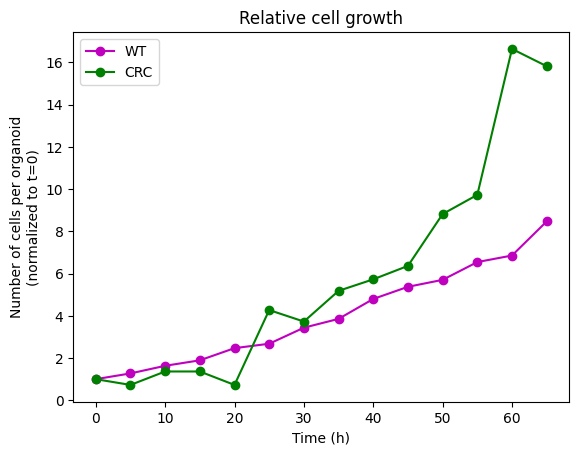

In [19]:
import matplotlib.pyplot as plt
print(summary_results)

# plot 1
plt.plot(summary_results["file"]*5, summary_results["%wt"], "m-", marker = "o", label = "WT")
plt.plot(summary_results["file"]*5, summary_results["%crc"], "g-", marker = "o", label = "CRC")

plt.title("% of cells per organoid over time")
plt.ylabel("% cells per organoid")
plt.xlabel("Time (h)")
plt.legend()

plt.show()

# plot 2
relative_wt = summary_results["wt_count"] / summary_results["wt_count"][0]
relative_crc = summary_results["crc_count"] / summary_results["crc_count"][0]

plt.plot(summary_results["file"] * 5, relative_wt, "m-", marker="o", label="WT")
plt.plot(summary_results["file"] * 5, relative_crc, "g-", marker="o", label="CRC")

plt.title("Relative cell growth")
plt.ylabel("Number of cells per organoid\n(normalized to t=0)")
plt.xlabel("Time (h)")
plt.legend()

plt.show()

In [24]:
import os
import re
import tifffile

input = r"C:\Users\6331823\Local SSD\Data_Anna\s65\s65.tif"
image = tifffile.imread(input)
print(image.shape)

input1 = r"C:\Users\6331823\Local SSD\Data_Anna\s55\s55.tif"
image1 = tifffile.imread(input1)
print(image1.shape)

(15, 3, 61, 1024, 1024)
(15, 61, 3, 1024, 1024)


In [ ]:
input_directory = r"C:\Users\6331823\Local SSD\Data_Anna\mixed\EXpansionLMix_12"

segmented = os.path.join(input_directory, "segmented")
cropped = os.path.join(input_directory, "cropped")
WT_channel = 0
CRC_channel = 1
all_ratios = []
frame_data = []

for file in range(15):
    segmented_stack = tifffile.imread(
        os.path.join(segmented, f"Frame-{file}_masks.tif")
    )
    frame = tifffile.imread(os.path.join(cropped, f"Frame-{file}.tif"))

    # Get properties of the masked nuclei, such as volume and location of every cell
    props = utils.properties_mask(segmented_stack)

    # Get properties of every cell in the WT and CRC channels at the masked nuclei locations
    frame_WT = frame[WT_channel, :, :, :]
    # threshold = frame_WT.copy()
    # threshold = utils.threshold(threshold)
    # blurred = ndimage.gaussian_filter(threshold, sigma=(0, 2, 2))

    median_value = np.median(frame_WT[frame_WT > 0])
    offset_image = frame_WT.astype(np.float32) - median_value
    offset_image[offset_image < 0] = 0  # Clip negative values
    offset_image = np.clip(offset_image, 0, 255).astype(np.uint16)
    df_wt = utils.properties_channel(segmented_stack, offset_image, "WT")

    frame_CRC = frame[CRC_channel, :, :, :]
    df_crc = utils.properties_channel(segmented_stack, frame_CRC, "CRC")

    # Combine the information of nuclei, WT, and CRC channel into a single dataframe
    df_final = props.merge(df_wt, on="label").merge(df_crc, on="label")
    df_final["file"] = file
    df_final["wt_crc_ratio"] = df_final.apply(
        lambda row: row["raw_WT"] / row["raw_CRC"] if row["raw_CRC"] != 0 else 5, axis=1
    )

    frame_data.append(df_final)

properties = pd.concat(frame_data, ignore_index=True)
print(properties)
ratios = properties["wt_crc_ratio"]

      label          z           y           x                  bounding_box  \
0         1   7.127551   46.301020   76.003401        (6, 37, 65, 9, 56, 85)   
1         2   6.462810   61.421488   48.839669        (6, 51, 39, 8, 75, 59)   
2         3   7.107450   67.340974   91.563037       (6, 58, 82, 9, 78, 103)   
3         4   7.208931   71.119617   68.886762        (6, 61, 59, 9, 81, 78)   
4         5   7.191077   96.287100   90.289040      (6, 84, 80, 9, 109, 103)   
...     ...        ...         ...         ...                           ...   
7818   1228  56.543103  558.685345  323.349138  (56, 551, 318, 58, 566, 331)   
7819   1229  56.388889  563.370370  333.438272  (56, 557, 327, 58, 571, 339)   
7820   1230  57.000000  419.983871  539.193548  (57, 413, 533, 58, 428, 545)   
7821   1231  57.000000  441.805369  519.281879  (57, 435, 513, 58, 449, 527)   
7822   1232  57.000000  537.000000  447.500000  (57, 533, 444, 58, 542, 452)   

      volume  area_WT     raw_WT  area_

In [15]:
import numpy as np
from sklearn.cluster import KMeans
import scipy.ndimage as ndimage

In [ ]:
channel_names = ["WT","CRC","Test","Nuclei"]

# Extract channel indices with a dictionary for dynamic access
channel_indices = {ch.lower(): i for i, ch in enumerate(channel_names) if ch.strip()}

# Always process the nuclei channel
nuclei_index = channel_indices.get("nuclei", -1)
if nuclei_index == -1:
    raise ValueError("Nuclei channel is required.")

# Placeholder for channel dataframes
channel_dfs = {}

for ch_name, ch_index in channel_indices.items():
    if ch_name == "nuclei":
        continue  # Skip nuclei for separate processing or if handled elsewhere

    # frame_ch = frame[ch_index, :, :, :]
    # offset_ch = utils.offset_image(frame_ch, type="median")
    # df_ch = utils.properties_channel(segmented_stack, offset_ch, channel_names[ch_index])
    # channel_dfs[ch_name.upper()] = df_ch

    print(ch_index, channel_names[ch_index])



0 WT
1 CRC
2 Test


TypeError: index expected at least 1 argument, got 0

In [3]:
import utils
import napari
from scipy.ndimage import gaussian_filter
from scipy.signal import wiener
import tifffile



Welcome to CellposeSAM, cellpose v
cellpose version: 	4.0.6 
platform:       	win32 
python version: 	3.11.13 
torch version:  	2.7.1+cu128! The neural network component of
CPSAM is much larger than in previous versions and CPU excution is slow. 
We encourage users to use GPU/MPS if available. 


utils package loaded successfully


In [11]:
input = r"C:\Users\6331823\Local SSD\Data_Anna\s65\cropped\Frame-14.tif"

WT_channel = 0
CRC_channel = 1
Nuclei_channel = 2


image = tifffile.imread(input)


image = image[CRC_channel,:,:,:]


threshold = image.copy()

threshold = utils.threshold(threshold)


blurred = gaussian_filter(threshold, sigma=(0, 2, 2))


offset_image = utils.offset_image(image, type="median")


viewer = napari.Viewer()


new_layer = viewer.add_image(image)


new_layer2 = viewer.add_image(threshold)


new_layer2 = viewer.add_image(blurred)


new_layer2 = viewer.add_image(offset_image)

In [ ]:
import tifffile
import scipy.ndimage as ndimage
from imaris_ims_file_reader.ims import ims
import numpy as np
import random

import os

input_directory = r"C:\Users\6331823\Local SSD\Data_Anna\crc"
output_directory = r"C:\Users\6331823\Local SSD\Train model whole organoid segmentation"

for file in os.listdir(input_directory):
    if file.endswith(".tif"):
        max_data = tifffile.imread(os.path.join(input_directory, file))
        max_data = max_data[:,:,2,:,:] # T Z X Y
        max_data = np.max(max_data, axis=1) # T X Y
        frames = random.sample(range(0, max_data.shape[0]), 4)

        for frame_n in frames:
            frame = max_data[frame_n,:,:]
            resize_factors = (200 / frame.shape[0], 200 / frame.shape[1])
            print(frame.shape)
            XY = ndimage.zoom(frame, resize_factors, order=0)
            XY = ndimage.gaussian_filter(XY, sigma=(2, 2))
            tifffile.imwrite(
                f"{os.path.join(output_directory,file.split('.')[0])}-{frame_n}_small.tif", XY
            )